In [1]:
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# data transaksi POS

transactions = [
    ['pen', 'bread', 'butter'],
    ['bread', 'butter', 'egg', 'milk'],
    ['vegetables', 'egg', 'milk'],
    ['bread', 'butter'],
    ['bread', 'butter', 'soy sauce', 'egg', 'milk']
]

df = pd.DataFrame({'Products purchased': transactions})

total_transactions = len(df)
print(f'Total Transaksi: {total_transactions}')

df.head()

Total Transaksi: 5


,Products purchased
0,"[pen, bread, butter]"
1,"[bread, butter, egg, milk]"
2,"[vegetables, egg, milk]"
3,"[bread, butter]"
4,"[bread, butter, soy sauce, egg, milk]"


In [3]:
# Membuat function support, confidence, & lift

def support(products):
    count = 0

    for transaction in transactions:
        # ubah ke set
        product_set = set(products)
        transaction_set = set(transaction)

        # cek apakah semua produk ada di transaksi
        if product_set.issubset(transaction_set):
            count += 1

    return count / total_transactions

def confidence(A, B):
    return support(A + B) / support(A)

def lift(A, B):
    return confidence(A, B) / support(B)

In [4]:
#List produk questin
list_products = [
    (['bread'], ['butter']),
    (['bread'], ['egg']),
    (['egg'], ['milk']),
    (['bread', 'butter'], ['milk'])
]

In [5]:
# Menghitung matrik
results = []

for A, B in list_products:
    sup = support(A + B)
    conf = confidence(A, B)
    lf = lift(A, B)

    results.append({
        'list products': f"{A} => {B}",
        'Support': sup,
        'Confidence': conf,
        'Lift': lf
    })

# Menampilkan hasil dalam DataFrame agar rapi
df_results = pd.DataFrame(results)
print(df_results)

                     list products  Support  Confidence      Lift
0          ['bread'] => ['butter']      0.8         1.0  1.250000
1             ['bread'] => ['egg']      0.4         0.5  0.833333
2              ['egg'] => ['milk']      0.6         1.0  1.666667
3  ['bread', 'butter'] => ['milk']      0.4         0.5  0.833333


**Analogi sederhana**

"Beli mie instan - beli telur"

1. Support -> berapa banyak transaksi ada mie + telur
2. Confidence -> dari yang beli mie, berapa yang beli telur
3. Lift -> apakah mie benar-benar bikin orang beli telur, atau memang teiur sudah sering dibeli semua orang

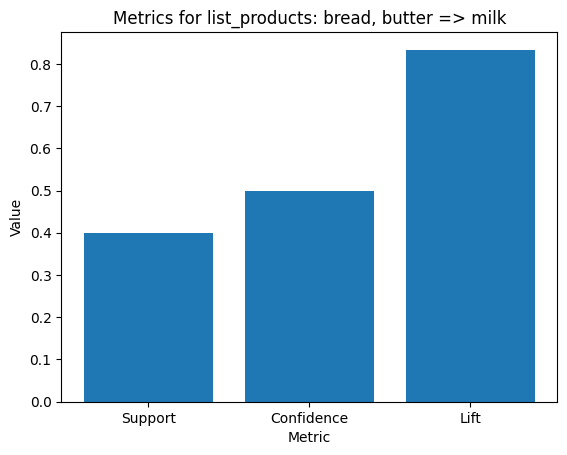

In [6]:
target_list_products = next(r for r in results if r['list products'] == "['bread', 'butter'] => ['milk']")

metrics = ['Support', 'Confidence', 'Lift']
values = [target_list_products[m] for m in metrics]

plt.figure()
plt.bar(metrics, values)
plt.title("Metrics for list_products: bread, butter => milk")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.show()

# **PRAKTIKUM MANDIRI 1**
Memasukkan data transaksi ke dalam DataFrame dan menampilkannya

In [13]:
from collections import defaultdict

In [26]:
# Data Transaksi
data_transaksi = {
    'ID Transaksi': ['T001','T002','T003','T004','T005',
                     'T006','T007','T008','T009','T010'],
    'No': list(range(1, 11)),
    'Item yang Dibeli': [
        'Laptop, Mouse, Keyboard, Headset',
        'Handphone, Charger, Casing HP',
        'Laptop, Mouse, Flashdisk',
        'Handphone, Headset, Power Bank, Charger',
        'Tablet, Keyboard, Mouse',
        'Laptop, Keyboard, Mouse, Headset',
        'Handphone, Casing HP, Flashdisk, Charger',
        'Laptop, Mouse, Headset, Power Bank',
        'Handphone, Charger, Power Bank',
        'Tablet, Mouse, Headset, Flashdisk'
    ]
}

df_transaksi = pd.DataFrame(data_transaksi)
print(f"Total transaksi: {len(df_transaksi)}")
df_transaksi

Total transaksi: 10


,ID Transaksi,No,Item yang Dibeli
0,T001,1,"Laptop, Mouse, Keyboard, Headset"
1,T002,2,"Handphone, Charger, Casing HP"
2,T003,3,"Laptop, Mouse, Flashdisk"
3,T004,4,"Handphone, Headset, Power Bank, Charger"
4,T005,5,"Tablet, Keyboard, Mouse"
5,T006,6,"Laptop, Keyboard, Mouse, Headset"
6,T007,7,"Handphone, Casing HP, Flashdisk, Charger"
7,T008,8,"Laptop, Mouse, Headset, Power Bank"
8,T009,9,"Handphone, Charger, Power Bank"
9,T010,10,"Tablet, Mouse, Headset, Flashdisk"


# **PRAKTIKUM MANDIRI 2**
Hitung frekuensi dan support untuk setiap item (1-Itemset)

In [29]:
# Parse item per transaksi
transaksi_list = []
for _, row in df_transaksi.iterrows():
    items = [item.strip() for item in row['Item yang Dibeli'].split(',')]
    transaksi_list.append({'ID Transaksi': row['ID Transaksi'], 'Items': items})

N = len(transaksi_list)   # Total transaksi = 10

# Hitung frekuensi & support
item_data = defaultdict(list)
for t in transaksi_list:
    for item in t['Items']:
        item_data[item].append(t['ID Transaksi'])

rows = []
for item, ids in item_data.items():
    frek = len(ids)
    supp = frek / N
    rows.append({
        'Item'      : item,
        'Transaksi' : ', '.join(ids),
        'Frekuensi' : frek,
        'Support'   : round(supp, 2)
    })

df_support_1 = (pd.DataFrame(rows)
                  .sort_values('Frekuensi', ascending=False)
                  .reset_index(drop=True))

print(f"Total item unik: {len(df_support_1)}  |  Total transaksi: {N}")
df_support_1

Total item unik: 10  |  Total transaksi: 10


,Item,Transaksi,Frekuensi,Support
0,Mouse,"T001, T003, T005, T006, T008, T010",6,0.6
1,Headset,"T001, T004, T006, T008, T010",5,0.5
2,Laptop,"T001, T003, T006, T008",4,0.4
3,Handphone,"T002, T004, T007, T009",4,0.4
4,Charger,"T002, T004, T007, T009",4,0.4
5,Keyboard,"T001, T005, T006",3,0.3
6,Flashdisk,"T003, T007, T010",3,0.3
7,Power Bank,"T004, T008, T009",3,0.3
8,Casing HP,"T002, T007",2,0.2
9,Tablet,"T005, T010",2,0.2


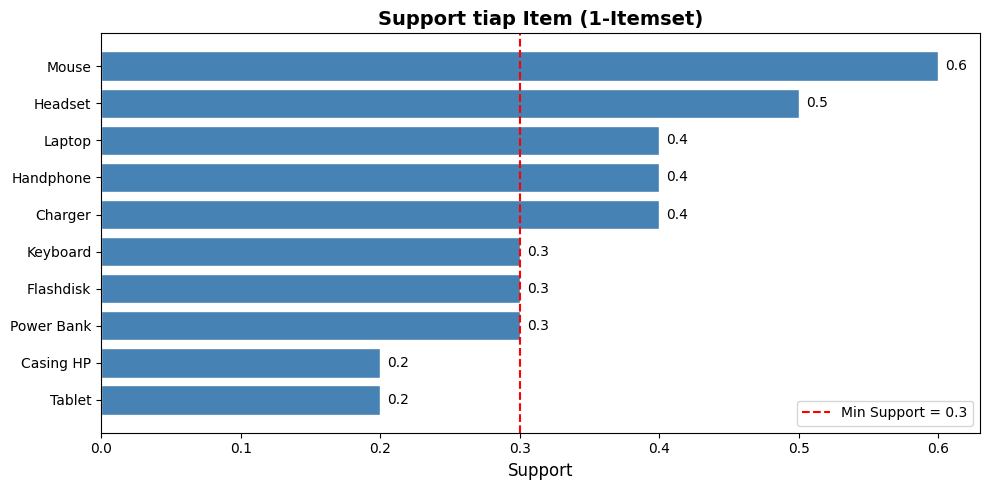

In [30]:
# Visualisasi

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_support_1['Item'], df_support_1['Support'],
               color='steelblue', edgecolor='white')
ax.axvline(x=0.3, color='red', linestyle='--', linewidth=1.5, label='Min Support = 0.3')
for bar, val in zip(bars, df_support_1['Support']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)
ax.set_xlabel('Support', fontsize=12)
ax.set_title('Support tiap Item (1-Itemset)', fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# **PRAKTIKUM MANDIRI 3**
Hitung frekuensi dan support untuk semua 2-itemset

In [31]:
# Hitung semua 2-itemset
pair_data = defaultdict(list)
for t in transaksi_list:
    for pair in combinations(sorted(t['Items']), 2):
        pair_data[pair].append(t['ID Transaksi'])

rows2 = []
for pair, ids in pair_data.items():
    frek = len(ids)
    supp = frek / N
    rows2.append({
        '2-Itemset' : '{' + ', '.join(pair) + '}',
        'Transaksi' : ', '.join(ids),
        'Frekuensi' : frek,
        'Support'   : round(supp, 2)
    })

df_support_2 = (pd.DataFrame(rows2)
                  .sort_values('Frekuensi', ascending=False)
                  .reset_index(drop=True))

print(f"Total 2-itemset: {len(df_support_2)}")
df_support_2

Total 2-itemset: 26


,2-Itemset,Transaksi,Frekuensi,Support
0,"{Laptop, Mouse}","T001, T003, T006, T008",4,0.4
1,"{Headset, Mouse}","T001, T006, T008, T010",4,0.4
2,"{Charger, Handphone}","T002, T004, T007, T009",4,0.4
3,"{Headset, Laptop}","T001, T006, T008",3,0.3
4,"{Keyboard, Mouse}","T001, T005, T006",3,0.3
5,"{Headset, Keyboard}","T001, T006",2,0.2
6,"{Keyboard, Laptop}","T001, T006",2,0.2
7,"{Casing HP, Charger}","T002, T007",2,0.2
8,"{Casing HP, Handphone}","T002, T007",2,0.2
9,"{Flashdisk, Mouse}","T003, T010",2,0.2


In [32]:
# Tampilkan hanya 2-itemset dengan support >= 0.3
df_support_2_filtered = df_support_2[df_support_2['Support'] >= 0.3].reset_index(drop=True)
print(f"2-Itemset yang memenuhi min_support=0.3 : {len(df_support_2_filtered)} pasangan")
df_support_2_filtered

2-Itemset yang memenuhi min_support=0.3 : 5 pasangan


,2-Itemset,Transaksi,Frekuensi,Support
0,"{Laptop, Mouse}","T001, T003, T006, T008",4,0.4
1,"{Headset, Mouse}","T001, T006, T008, T010",4,0.4
2,"{Charger, Handphone}","T002, T004, T007, T009",4,0.4
3,"{Headset, Laptop}","T001, T006, T008",3,0.3
4,"{Keyboard, Mouse}","T001, T005, T006",3,0.3


# **PRAKTIKUM MANDIRI 4**
Threshold: min_support = 0.3, min_confidence = 0.5

In [33]:
# Helper: hitung support
def get_support(items_check):
    s = set(items_check)
    count = sum(1 for t in transaksi_list if s.issubset(set(t['Items'])))
    return count / N

MIN_SUPPORT    = 0.3
MIN_CONFIDENCE = 0.5

Soal 1 Support {Mouse} dan {Headset}

In [34]:
supp_mouse   = get_support(['Mouse'])
supp_headset = get_support(['Headset'])

print(f"Support(Mouse)   = {supp_mouse:.1f}  ({supp_mouse*100:.0f}%)")
print(f"Support(Headset) = {supp_headset:.1f}  ({supp_headset*100:.0f}%)")

Support(Mouse)   = 0.6  (60%)
Support(Headset) = 0.5  (50%)


Soal 2 Support 2-itemset {Handphone, Charger}

In [35]:
supp_hp_ch = get_support(['Handphone', 'Charger'])
print(f"Support(Handphone, Charger) = {supp_hp_ch:.1f}  ({supp_hp_ch*100:.0f}%)")

Support(Handphone, Charger) = 0.4  (40%)


Soal 3 dan 4 Confidence Handphone => Charger

In [36]:
supp_hp  = get_support(['Handphone'])
supp_ch  = get_support(['Charger'])
supp_hpch = get_support(['Handphone', 'Charger'])

conf_hp_ch = supp_hpch / supp_hp
conf_ch_hp = supp_hpch / supp_ch

print(f"Confidence(Handphone => Charger) = {supp_hpch:.1f}/{supp_hp:.1f} = {conf_hp_ch:.3f} ({conf_hp_ch*100:.1f}%)")
print(f"Confidence(Charger => Handphone) = {supp_hpch:.1f}/{supp_ch:.1f} = {conf_ch_hp:.3f} ({conf_ch_hp*100:.1f}%)")

Confidence(Handphone => Charger) = 0.4/0.4 = 1.000 (100.0%)
Confidence(Charger => Handphone) = 0.4/0.4 = 1.000 (100.0%)


Soal 5 Lift Handphone => Charger

In [37]:
lift_hp_ch = supp_hpch / (supp_hp * supp_ch)
print(f"Lift(Handphone => Charger) = {supp_hpch:.1f} / ({supp_hp:.1f} x {supp_ch:.1f})")
print(f"                           = {supp_hpch:.1f} / {supp_hp*supp_ch:.2f} = {lift_hp_ch:.3f}")
print("→ Lift > 1: Handphone dan Charger saling berpengaruh positif ✅")

Lift(Handphone => Charger) = 0.4 / (0.4 x 0.4)
                           = 0.4 / 0.16 = 2.500
→ Lift > 1: Handphone dan Charger saling berpengaruh positif ✅


Soal 6,7,8,9 Support, Confidence & Lift Mouse => Headset

In [38]:
supp_mo   = get_support(['Mouse'])
supp_hd   = get_support(['Headset'])
supp_mohd = get_support(['Mouse', 'Headset'])

conf_mo_hd = supp_mohd / supp_mo
conf_hd_mo = supp_mohd / supp_hd
lift_mo_hd = supp_mohd / (supp_mo * supp_hd)

print(f"Support(Mouse, Headset)          = {supp_mohd:.1f}  ({supp_mohd*100:.0f}%)")
print(f"Confidence(Mouse => Headset)     = {supp_mohd:.1f}/{supp_mo:.1f} = {conf_mo_hd:.3f} ({conf_mo_hd*100:.1f}%)")
print(f"Confidence(Headset => Mouse)     = {supp_mohd:.1f}/{supp_hd:.1f} = {conf_hd_mo:.3f} ({conf_hd_mo*100:.1f}%)")
print(f"Lift(Mouse => Headset)           = {supp_mohd:.1f} / ({supp_mo:.1f}x{supp_hd:.1f}) = {lift_mo_hd:.3f}")

Support(Mouse, Headset)          = 0.4  (40%)
Confidence(Mouse => Headset)     = 0.4/0.6 = 0.667 (66.7%)
Confidence(Headset => Mouse)     = 0.4/0.5 = 0.800 (80.0%)
Lift(Mouse => Headset)           = 0.4 / (0.6x0.5) = 1.333


Soal 10 Kesimpulan: Aturan Mana yang VALID?

In [39]:
rules = [
    ('Handphone', 'Charger'),
    ('Charger',   'Handphone'),
    ('Mouse',     'Headset'),
    ('Headset',   'Mouse'),
]

summary = []
for ant, cons in rules:
    supp = get_support([ant, cons])
    sa   = get_support([ant])
    sc   = get_support([cons])
    conf = supp / sa
    lift = supp / (sa * sc)
    valid = supp >= MIN_SUPPORT and conf >= MIN_CONFIDENCE
    summary.append({
        'Aturan'        : f'{ant} => {cons}',
        'Support'       : round(supp, 2),
        'Confidence'    : round(conf, 3),
        'Lift'          : round(lift, 3),
        'Supp ≥ 0.3'   : '✅' if supp >= MIN_SUPPORT else '❌',
        'Conf ≥ 0.5'   : '✅' if conf >= MIN_CONFIDENCE else '❌',
        'VALID?'        : '✅ VALID' if valid else '❌ TIDAK'
    })

df_kesimpulan = pd.DataFrame(summary)
df_kesimpulan

,Aturan,Support,Confidence,Lift,Supp ≥ 0.3,Conf ≥ 0.5,VALID?
0,Handphone => Charger,0.4,1.000,2.500,✅,✅,✅ VALID
1,Charger => Handphone,0.4,1.000,2.500,✅,✅,✅ VALID
2,Mouse => Headset,0.4,0.667,1.333,✅,✅,✅ VALID
3,Headset => Mouse,0.4,0.800,1.333,✅,✅,✅ VALID
